<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 6 — Perceptrón, MLP, Backpropagation y Métricas Clínicas</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

En el Challenge 5 trabajaste con el dataset **Breast Cancer Wisconsin** como problema no supervisado: aplicaste PCA, K-means y DBSCAN sin usar las etiquetas durante el entrenamiento.

Ahora usaremos el **mismo contexto biomédico**, pero como problema supervisado de clasificación binaria. Cada muestra corresponde a características morfológicas calculadas a partir de imágenes digitalizadas de aspirado con aguja fina (FNA) de masa mamaria. El objetivo será entrenar modelos neuronales en **PyTorch** para clasificar si una muestra corresponde a un tumor **maligno** o **benigno**.

**Pregunta clínica:** ¿puede una red neuronal simple mejorar la clasificación diagnóstica frente a un perceptrón/modelo lineal? ¿Qué métrica debería priorizarse si el error más crítico es no detectar un tumor maligno?

---
> **Fuente:** Wolberg, W. H. et al. (1995). *Breast Cancer Wisconsin (Diagnostic) Dataset*. UCI ML Repository.  
> Disponible directamente en `sklearn.datasets.load_breast_cancer()` — no requiere descarga.

### Estructura de carpetas
```text
Clase10_Challenge6/
└── Challenge6_ApellidoNombre.ipynb    ← no se necesita CSV externo
```

**Nota importante:** en `sklearn`, la etiqueta original es `0 = malignant` y `1 = benign`. En este challenge invertiremos la codificación para trabajar clínicamente con:

```text
0 = benigno
1 = maligno  ← clase positiva clínica
```


---
## Ejercicio 1 — Diseño previo al código

### 1.1 — Neurona artificial, perceptrón y MLP

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

**1.** Completa la expresión general de una neurona artificial:

$$z = w * x + b \qquad ; \qquad a = \phi(z)$$

¿Qué representan $\mathbf{x}$, $\mathbf{w}$, $b$ y $\phi$ en este problema biomédico?

**📝 Tu respuesta:** $x$ representa las características de entrada, $w$ va asociada al peso otorgado a a cada característica, $b$ es el sesgo y $\phi$ representa la función de activación (transformación no lineal).

---

**2.** Explica la diferencia entre un perceptrón/modelo lineal y un MLP.

| Modelo | ¿Qué aprende? | Tipo de frontera de decisión |
|---|---|---|
| Perceptrón / modelo lineal | Perceptron Learning Rule, ajusta pesos solo cuando se cometen errrores| lineal |
| MLP | 	Backpropagation + Gradient Descent, ve cuanto contribuye cada peso y ajusta todos para reducir el error | no lineal|

---

**3.** ¿Por qué una salida de una sola neurona puede ser suficiente para clasificación binaria?

**📝 Tu respuesta:** Porque se busca una respuesta simple y una interpretación directa, una sola neurona puede recibir gran cantidad de inputs y brinda un solo output como un escalar entre cero y uno. Valores de probabilidad cerca a 1 indican una clase positiva y cerca a 0, una clase negativa.

---

**4.** En clasificación benigno/maligno, ¿qué error clínico es más grave: falso positivo o falso negativo? ¿Por qué?

**📝 Tu respuesta:** Es más grave un falso negativo, esto se debe a que en medicina el proceso de diagnóstico permite volver a testear a falsos postivos con más facilidad mientras que a los falsos negativos se les descarta por su resultado provocando que el paciente vaya a casa sin tratamiento.

### 1.2 — Backpropagation y función de pérdida

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

Para clasificación binaria usaremos una pérdida tipo Binary Cross-Entropy.

**1.** Completa:

$$\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

$$\mathcal{L}_{BCE} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat{p}i) + (1-y_i)\log(1-\hat{p}i)\right]$$

---

**2.** Ordena los pasos de entrenamiento en PyTorch:

| Paso | Código PyTorch | ¿Qué hace? |
|---|---|---|
| 1 | `logits = model(X_batch)` | Generar predicciones en el forward pass |
| 2 | `loss = loss_fn(logits, y_batch)` | Cálculo de pérdida actual |
| 3 | `optimizer.zero_grad()` |Limpiar gradienets del lote anterior|
| 4 | `loss.backward()` | Cálculo de gradientes mediante backward pass|
| 5 | `optimizer.step()` | Actualizar pesos y minimizar error|

---

**3.** ¿Por qué en PyTorch primero calculamos la pérdida y recién después llamamos a `loss.backward()`?

**📝 Tu respuesta:** Primero se debe calcular la pérdida porque cuantifica el error entre predicción y etiquetas reales. Después usamos backpropagation para calcular gradientes y ajustar los pesos para minimizar el error. Si no calculamos primero la pérdida, no hay función forma ni de calcular gradientes ni de medir errores.


### 1.3 — Pipeline completo

Completa el siguiente pipeline:

```text
load_breast_cancer()
        │
        ▼
[ Paso A ] Invertir etiquetas
        │
        ▼
[ Paso B ] Split estratificado: train_test_split (..., stratify=y)
        │
        ▼
[ Paso C ] StandardScaler
           fit en X_train ; transform en X_train y X_test
        │
        ▼
[ Paso D ] Conversión a torch.Tensor
           X: torch.float32 ; y: torch.float32 con shape (N,1)
        │
        ▼
[ Paso E ] Definición de modelos y función de pérdida
           (BCEWithLogitsLoss)
        │
        ├──── Modelo 1: Perceptrón / clasificador lineal
        │
        └──── Modelo 2: Red neuronal multicapa (MLP) con capa oculta y ReLU
        │
        ▼
[ Paso F ] Entrenamiento explícito:
           forward → loss → zero_grad → backgrad → step
        │
        ▼
[ Paso G ] Evaluación clínica:
           matriz de confusión, accuracy, sensibilidad,
           especificidad, precisión, F1, ROC-AUC
```


**📝 Tu respuesta:** completa los blancos arriba.


---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 2.1 — Librerías

In [ ]:
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'
UPCH_GRAY   = '#4A4A4A'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TODO 1: importa PyTorch y sus módulos principales
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_breast_cancer

# TODO 2: importa train_test_split, StandardScaler y métricas clínicas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                            classification_report, ConfusionMatrixDisplay,
                            precision_score, recall_score, f1_score, roc_curve,
                            roc_auc_score)

plt.rcParams['figure.dpi'] = 120

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# TODO 3: selecciona GPU si está disponible; si no, CPU
device = 'cpu'
print(f'Setup completo ✓ | device = {device}')

Setup completo ✓ | device = cpu


### Paso 2.2 — Carga del dataset y recodificación clínica

In [ ]:
# ── Carga del dataset ──────────────────────────────────────────
data = load_breast_cancer()
X = data.data.astype(np.float32)
feature_names = data.feature_names

# sklearn: 0 = malignant, 1 = benign
# challenge: 0 = benigno, 1 = maligno (clase positiva clínica)
# TODO 4: invierte la etiqueta original para que 1 sea maligno
y = 1 - data.target

label_map = {0: 'Benigno', 1: 'Maligno'}
df = pd.DataFrame(X, columns=feature_names)
df['diagnosis'] = y

print(f'Shape X: {X.shape}')
print(f'Número de features: {X.shape[1]}')
print('Codificación usada en este challenge: 0=Benigno, 1=Maligno')
print('\nDistribución de clases:')
print(df['diagnosis'].map(label_map).value_counts())
df.head()

Shape X: (569, 30)
Número de features: 30
Codificación usada en este challenge: 0=Benigno, 1=Maligno

Distribución de clases:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.990000,10.380000,122.800003,1001.000000,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.330000,184.600006,2019.000000,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.570000,17.770000,132.899994,1326.000000,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.410000,158.800003,1956.000000,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.690001,21.250000,130.000000,1203.000000,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.530001,152.500000,1709.000000,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.420000,20.379999,77.580002,386.100006,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.500000,98.870003,567.700012,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.290001,14.340000,135.100006,1297.000000,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.670000,152.199997,1575.000000,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### Paso 2.3 — EDA inicial

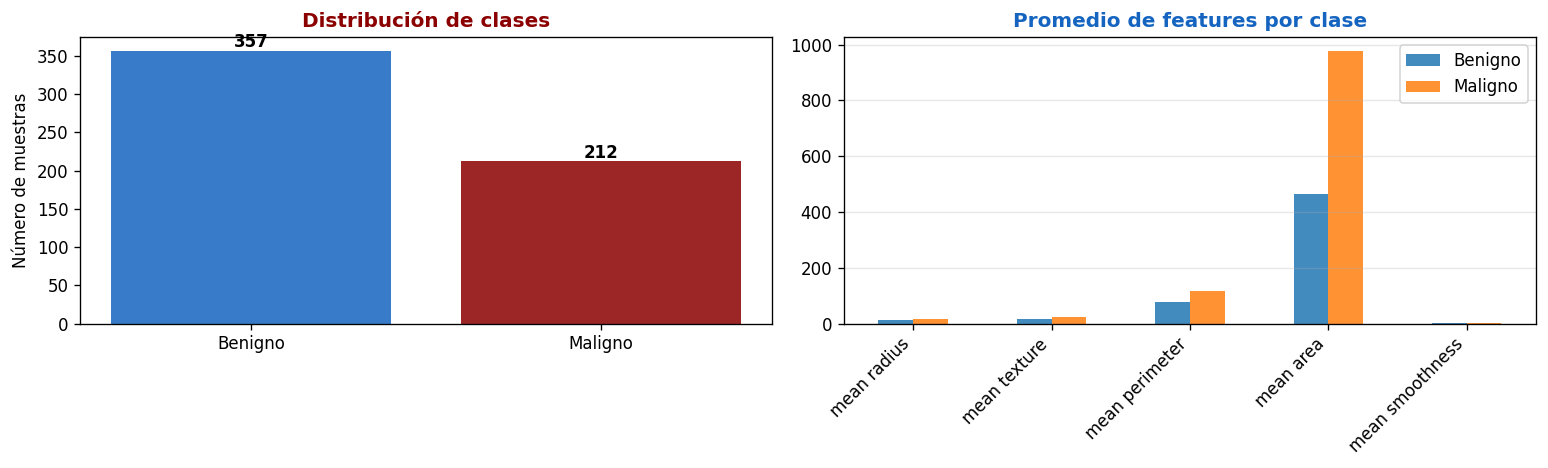

Resumen estadístico de las primeras 5 variables:


mean radius                                                  \
                count   mean   std    min    25%    50%    75%    max   
diagnosis                                                               
0               357.0  12.15  1.78   6.98  11.08  12.20  13.37  17.85   
1               212.0  17.46  3.20  10.95  15.08  17.32  19.59  28.11   

          mean texture         ... mean area         mean smoothness        \
                 count   mean  ...       75%     max           count  mean   
diagnosis                      ...                                           
0                357.0  17.91  ...    551.10   992.1           357.0  0.09   
1                212.0  21.60  ...   1203.75  2501.0           212.0  0.10   

                                               
            std   min   25%   50%   75%   max  
diagnosis                                      
0          0.01  0.05  0.08  0.09  0.10  0.16  
1          0.01  0.07  0.09  0.10  0.11  0.14  

[2 rows x 40 columns]

In [ ]:
# ── Distribución de clases y resumen de features ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['diagnosis'].map(label_map).value_counts()
axes[0].bar(counts.index, counts.values, color=[UPCH_BLUE, UPCH_RED], alpha=0.85)
axes[0].set_title('Distribución de clases', fontsize=12, fontweight='bold', color=UPCH_RED)
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
df.groupby('diagnosis')[selected_features].mean().T.plot(kind='bar', ax=axes[1], alpha=0.85)
axes[1].set_title('Promedio de features por clase', fontsize=12, fontweight='bold', color=UPCH_BLUE)
axes[1].set_xticklabels(selected_features, rotation=45, ha='right')
axes[1].legend(['Benigno', 'Maligno'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('challenge6_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumen estadístico de las primeras 5 variables:')
df[selected_features + ['diagnosis']].groupby('diagnosis').describe().round(2)

### Paso 2.4 — Interpretación inicial

**📝 Tu respuesta (edita esta celda):**

**1. ¿El dataset está balanceado o desbalanceado?**  
El dataset se encuentra moderadamente desbalanceado ya que para la clase maligno hay 37% y para benigno es 63%. Esto significa que preliminarmente habría cierto sesgo a diagnosticar los casos como benignos.


**2. ¿Qué diferencias observas entre benigno y maligno en las variables exploradas?**  
Se observa principalmente que hay diferencias significativas en las variables para malignos (valores altos) y beingnos (valores más bajos) pero para mean area se observa la mayor diferencia, esto se puede dar porque la escala es numéricamente más alta. Es por ello que lo mejor en casos como estos es normalizar para evitar que el modelo solo escoja una característica como la de mayor peso.

**3. ¿Qué métrica clínica deberíamos cuidar más si nos preocupa no perder casos malignos?**  
Recall o sensibilidad puesto que se encarga de detectar los casos positivos y falsos negativos. En clínica es crucial identificar a los pacientes con casos malignos ya que se les debe dar un tratamiento. A los falsos negativos, se les descarta rápidamente perdiendo una oportunidad de un diagnóstico oportuno.

**4. ¿Por qué será necesario escalar las variables antes de entrenar una red neuronal?**  
Es  necesario ya que las redes neuronales son sensibles a magnitudes grandes. Pueden priorizar las variables con mayor notación numérica, de esta forma ignorando otras con igual o mayor nivel predictivo lo cual puede generar una minimización de error no óptima.


---
# PARTE 1 — De datos tabulares a tensores PyTorch
## Ejercicio 3 — Split, escalado y DataLoader

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 3.1 — Train / validation / test split

In [ ]:
# ── Split estratificado ─────────────────────────────────────────
# TODO 5: separa primero test = 20% manteniendo proporción de clases
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TODO 6: separa validation a partir de trainval
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify= y_trainval
)

print(f'Train:      {X_train.shape} | malignos={y_train.sum()}')
print(f'Validation: {X_val.shape} | malignos={y_val.sum()}')
print(f'Test:       {X_test.shape} | malignos={y_test.sum()}')

Train:      (364, 30) | malignos=136
Validation: (91, 30) | malignos=34
Test:       (114, 30) | malignos=42


### Paso 3.2 — Escalado sin data leakage

In [ ]:
# ── StandardScaler: fit SOLO en train ───────────────────────────
scaler = StandardScaler()

# TODO 7: ajusta el scaler solo en train y transforma train/val/test
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Media aproximada train escalado:', X_train_sc.mean(axis=0)[:3].round(4))
print('Desv. estándar train escalado:', X_train_sc.std(axis=0)[:3].round(4))

Media aproximada train escalado: [-0. -0.  0.]
Desv. estándar train escalado: [1. 1. 1.]


### Paso 3.3 — Conversión a tensores y creación de DataLoaders

In [ ]:
# ── Conversión a tensores ───────────────────────────────────────
# TODO 8: convierte X a tensores float32
X_train_t = torch.tensor(X_train_sc, dtype= torch.float32)
X_val_t   = torch.tensor(X_val_sc, dtype= torch.float32)
X_test_t  = torch.tensor(X_test_sc, dtype= torch.float32)

# TODO 9: convierte y a tensores float32 con shape (N, 1)
y_train_t = torch.tensor(y_train, dtype= torch.float32).view(-1,1)
y_val_t   = torch.tensor(y_val, dtype= torch.float32).view(-1,1)
y_test_t  = torch.tensor(y_test, dtype= torch.float32).view(-1,1)

BATCH_SIZE = 32

# TODO 10: crea TensorDataset y DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)

print(f'X_train_t: {X_train_t.shape} | y_train_t: {y_train_t.shape}')
print(f'Número de mini-batches train: {len(train_loader)}')

X_train_t: torch.Size([364, 30]) | y_train_t: torch.Size([364, 1])
Número de mini-batches train: 12


### Paso 3.4 — Inspección de un mini-batch

In [ ]:
# ── Inspección de mini-batch ────────────────────────────────────
X_batch, y_batch = next(iter(train_loader))
print(f'X_batch shape: {X_batch.shape}')
print(f'y_batch shape: {y_batch.shape}')
print(f'Primeras etiquetas del batch: {y_batch[:8].view(-1).numpy().astype(int)}')
print('\nInterpretación: cada fila tiene ___ features; cada etiqueta tiene shape ___ para BCEWithLogitsLoss.')

X_batch shape: torch.Size([32, 30])
y_batch shape: torch.Size([32, 1])
Primeras etiquetas del batch: [1 0 0 0 0 1 0 0]

Interpretación: cada fila tiene ___ features; cada etiqueta tiene shape ___ para BCEWithLogitsLoss.


In [ ]:
print('\nInterpretación: cada fila tiene 30 features; cada etiqueta tiene shape torch.Size([batch_size, 1]) para BCEWithLogitsLoss.')

### Paso 3.5 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿Qué representa la dimensión 30 en `X_batch`?**  
Representa las 30 características geométricas y de forma de las imagénes. Cada fila contiene estos 30 valores.

**2. ¿Por qué `y_batch` tiene shape `(batch_size, 1)`?**  
Porque al ser un modelo de clasificación binaria solo es necesaria una neurona de salida.

**3. ¿Por qué usamos `shuffle=True` en train y `shuffle=False` en validation/test?**  
Usamos True para mezclar los valores a cargar en el entrenamiento del modelo de redes neuronales, brinda aleatoriedad evitando que el modelo aprenda el orden de los datos. En validation/test se usa False ya que sirven para evaluar el modelo y no requieren ese cuidado.

**4. ¿Para qué nos sirve separar validation y test?**  
Validación sirve para ajustar hiperparametros y mejorar el modelo, mientras que Test es necesario para probar el modelo final y debe verse solo una vez, es un control externo del modelo. Aplicar esta división previene el overfitting y el data leakage.


---
# PARTE 2 — Perceptrón / Clasificador Lineal en PyTorch
## Ejercicio 4 — Modelo lineal, entrenamiento y backpropagation

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 4.1 — Definición del modelo lineal

In [ ]:
# ── Perceptrón / modelo lineal para clasificación binaria ──────
class LogisticPerceptron(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # TODO 11: una capa lineal que reciba n_features y devuelva 1 logit
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        # TODO 12: calcula el logit
        logits = self.linear(x)
        return logits

n_features = X_train_t.shape[1]
perceptron = LogisticPerceptron(n_features).to(device)
print(perceptron)
print(f'Número de parámetros entrenables: {sum(p.numel() for p in perceptron.parameters())}')

LogisticPerceptron(
  (linear): Linear(in_features=30, out_features=1, bias=True)
)
Número de parámetros entrenables: 31


### Paso 4.2 — Funciones de entrenamiento y evaluación

In [ ]:
# ── Funciones reutilizables de entrenamiento ───────────────────
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # TODO 13: completa el flujo forward → loss → zero_grad → backward → step
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate_loss(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs=100, device=device):
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss   = evaluate_loss(model, val_loader, loss_fn, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch == 1 or epoch % 25 == 0:
            print(f'Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')

    return history

### Paso 4.3 — Entrenamiento del perceptrón

In [ ]:
# ── Entrenamiento del modelo lineal ─────────────────────────────
seed_everything(42)
perceptron = LogisticPerceptron(n_features).to(device)

# TODO 14: define la pérdida y el optimizador
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(perceptron.parameters(), lr=0.01)

hist_perc = train_model(perceptron, train_loader, val_loader,
                        loss_fn, optimizer, epochs=100, device=device)

Epoch 001 | train_loss=0.4516 | val_loss=0.2860
Epoch 025 | train_loss=0.0661 | val_loss=0.0770
Epoch 050 | train_loss=0.0536 | val_loss=0.0754
Epoch 075 | train_loss=0.0467 | val_loss=0.0791
Epoch 100 | train_loss=0.0425 | val_loss=0.0824


### Paso 4.4 — Curvas de pérdida

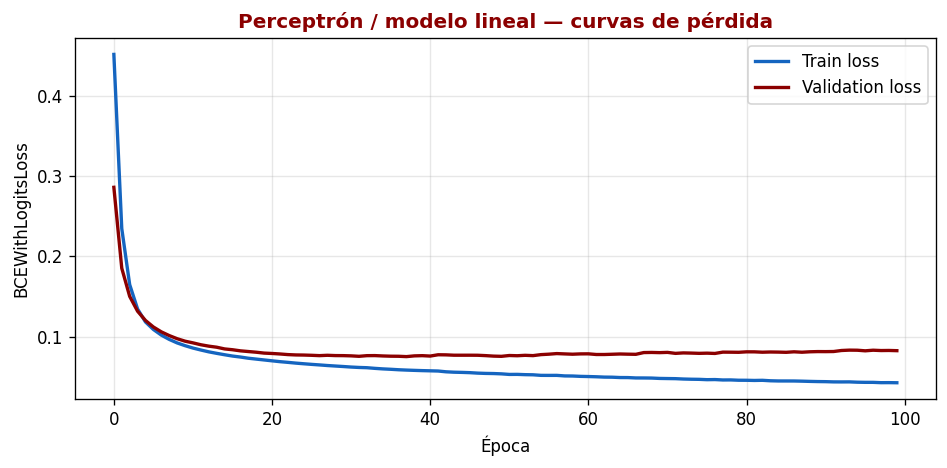

In [ ]:
# ── Curvas de pérdida ───────────────────────────────────────────
def plot_history(history, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history['train_loss'], label='Train loss', color=UPCH_BLUE, lw=2)
    ax.plot(history['val_loss'], label='Validation loss', color=UPCH_RED, lw=2)
    ax.set_xlabel('Época')
    ax.set_ylabel('BCEWithLogitsLoss')
    ax.set_title(title, fontsize=12, fontweight='bold', color=UPCH_RED)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(hist_perc, 'Perceptrón / modelo lineal — curvas de pérdida')

### Paso 4.5 — Funciones de predicción y métricas clínicas

In [ ]:
# ── Predicción y métricas clínicas ──────────────────────────────
@torch.no_grad()
def predict_proba(model, X_tensor, device):
    model.eval()
    logits = model(X_tensor.to(device))
    # TODO 15: convierte logits a probabilidades con sigmoid
    probs = torch.sigmoid(logits).cpu().numpy().ravel()
    return probs


def clinical_metrics(y_true, y_prob, threshold=0.5):
    # TODO 16: convierte probabilidades a clases usando threshold
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'sensitivity_recall_malignant': recall_score(y_true, y_pred, pos_label=1),
        'specificity_benign': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'precision_malignant': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_malignant': f1_score(y_true, y_pred, pos_label=1),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }


def plot_confusion(y_true, y_prob, title, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Reds')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benigno', 'Maligno'])
    ax.set_yticklabels(['Benigno', 'Maligno'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(title, fontsize=11, fontweight='bold', color=UPCH_RED)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

### Paso 4.6 — Evaluación del perceptrón

In [ ]:
# ── Evaluación del perceptrón en test ───────────────────────────
y_prob_perc = predict_proba(perceptron, X_test_t, device)
metrics_perc = clinical_metrics(y_test, y_prob_perc, threshold=0.5)

pd.DataFrame([metrics_perc]).T.rename(columns={0: 'Perceptrón'}).round(4)

,Perceptrón
threshold,0.5000
accuracy,0.9737
sensitivity_recall_malignant,0.9524
specificity_benign,0.9861
precision_malignant,0.9756
f1_malignant,0.9639
roc_auc,0.9944
tn,71.0000
fp,1.0000
fn,2.0000


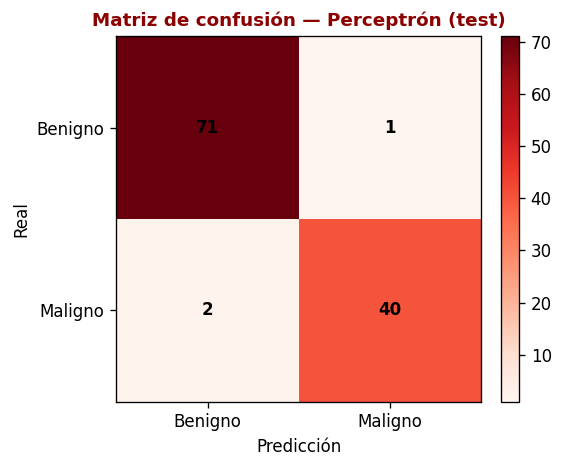

In [ ]:
plot_confusion(y_test, y_prob_perc,
               title='Matriz de confusión — Perceptrón (test)',
               threshold=0.5)

### Paso 4.7 — Interpretación del perceptrón

**📝 Tu respuesta (edita esta celda):**

**1. ¿La pérdida de train y validation disminuye de forma coherente?**

La pérdida si disminuye de forma coherente puesto que tiene un comportamiento y tendencia similar. Aunque al final la pérdida de validación aumenta comparada con la de entrenamiento, la diferencia es pequeña como para indicar sobreajuste.
___

**2. ¿El perceptrón parece suficiente para este problema? Justifica con métricas.**
Se obtiene un accuracy de 97.37%, una sensibilidad para malignidad de 95.24%, una especificidad de 98.61%, un F1-score de 96.39% y un ROC-AUC de 0.9944. Estas métricas muestran una buena generalización. Además, agregando información de la matriz de confusión se observa una gran capacidad para diferencias malignos y benignos.
___

**3. ¿Cuántos falsos negativos obtuvo el modelo? ¿Por qué son clínicamente importantes?**

Los falsos negativos obtenidos fueron 2, son clínicamente importantes ya que los resultados predichos son incorrectos y califican la gravedad del tumor como menor frente a los casos malignos lo cual puede retrasar el diagnóstico y el tratamiento del cáncer. Sería importante dar un seguimiento clínico a ellos y respecto a la data, identificar las carácteristicas que causan confusión en el modelo.
___

**4. Si se quisiera aumentar la sensibilidad para malignidad, ¿qué podríamos modificar en la etapa de decisión?**

Podríamos disminuir el threshold para clasificar más casos como malignos. De esta forma, aumenta la sensibilidad y se reducen falsos negativos.
___


---
# PARTE 3 — Multi-Layer Perceptron y Backpropagation
## Ejercicio 5 — MLP para clasificación diagnóstica

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>


### Paso 5.1 — Definición del MLP

In [ ]:
# ── MLP simple para datos tabulares ─────────────────────────────
class MLPClassifier(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

seed_everything(42)
mlp = MLPClassifier(n_features).to(device)
print(mlp)
print(f'Número de parámetros entrenables: {sum(p.numel() for p in mlp.parameters())}')

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)
Número de parámetros entrenables: 641


### Paso 5.2 — Entrenamiento del MLP

In [ ]:
# ── Entrenamiento del MLP ───────────────────────────────────────
# TODO 17: define pérdida y optimizador para el MLP
loss_fn_mlp = nn.BCEWithLogitsLoss()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=0.001, weight_decay=1e-4)

hist_mlp = train_model(mlp, train_loader, val_loader,
                       loss_fn_mlp, optimizer_mlp, epochs=150, device=device)

Epoch 001 | train_loss=0.6905 | val_loss=0.6774
Epoch 025 | train_loss=0.0832 | val_loss=0.0899
Epoch 050 | train_loss=0.0424 | val_loss=0.0757
Epoch 075 | train_loss=0.0241 | val_loss=0.0810
Epoch 100 | train_loss=0.0122 | val_loss=0.0835
Epoch 125 | train_loss=0.0060 | val_loss=0.0898
Epoch 150 | train_loss=0.0037 | val_loss=0.0951


### Paso 5.3 — Comparación de curvas de pérdida

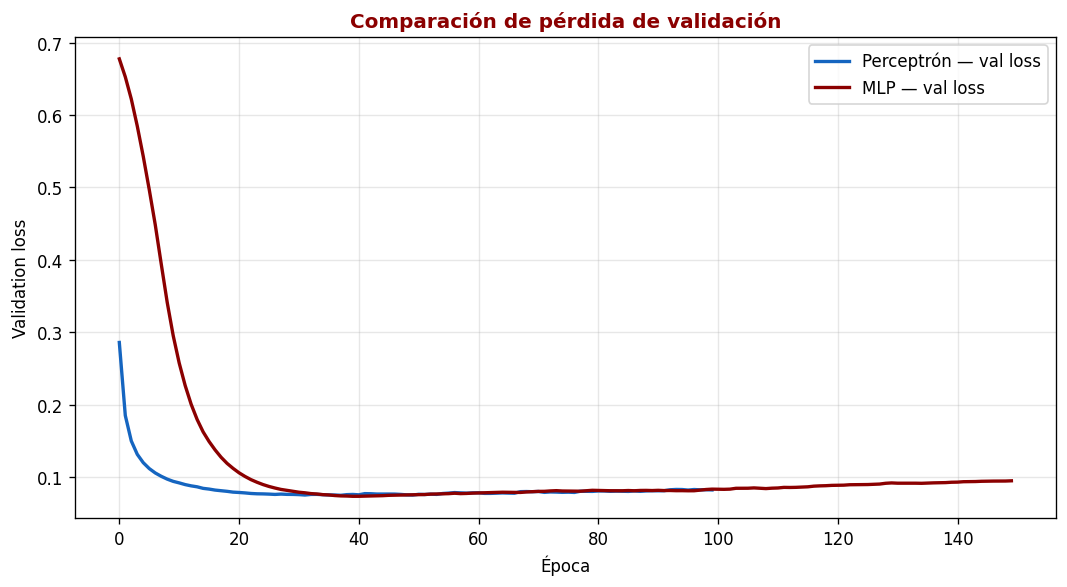

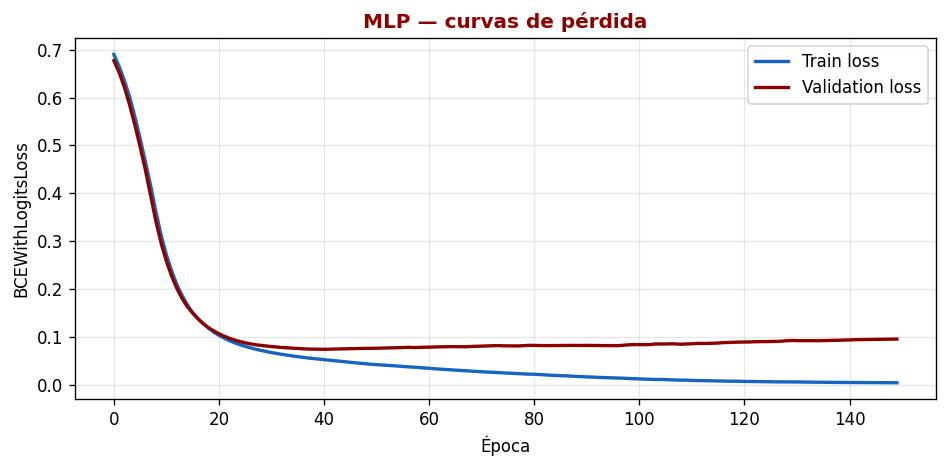

In [ ]:
# ── Comparación de curvas ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_perc['val_loss'], label='Perceptrón — val loss', color=UPCH_BLUE, lw=2)
ax.plot(hist_mlp['val_loss'], label='MLP — val loss', color=UPCH_RED, lw=2)
ax.set_xlabel('Época')
ax.set_ylabel('Validation loss')
ax.set_title('Comparación de pérdida de validación', fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge6_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

plot_history(hist_mlp, 'MLP — curvas de pérdida')

### Paso 5.4 — Evaluación del MLP

In [ ]:
# ── Evaluación del MLP en test ─────────────────────────────────
# TODO 18: predice probabilidades del MLP y calcula métricas clínicas
y_prob_mlp = predict_proba(mlp, X_test_t, device)
metrics_mlp = clinical_metrics(y_test, y_prob_mlp, threshold=0.5)

comparison = pd.DataFrame([metrics_perc, metrics_mlp], index=['Perceptrón', 'MLP'])
comparison[['accuracy', 'sensitivity_recall_malignant', 'specificity_benign',
            'precision_malignant', 'f1_malignant', 'roc_auc', 'fn', 'fp']].round(4)

,accuracy,sensitivity_recall_malignant,specificity_benign,precision_malignant,f1_malignant,roc_auc,fn,fp
Perceptrón,0.9737,0.9524,0.9861,0.9756,0.9639,0.9944,2,1
MLP,0.9737,0.9524,0.9861,0.9756,0.9639,0.9954,2,1


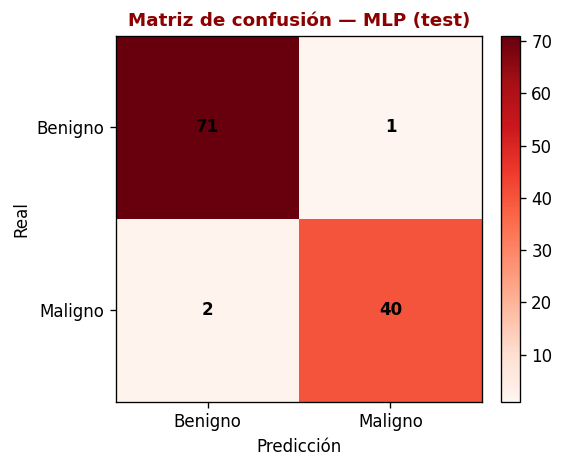

In [ ]:
plot_confusion(y_test, y_prob_mlp,
               title='Matriz de confusión — MLP (test)',
               threshold=0.5)

### Paso 5.5 — Interpretación MLP vs perceptrón

**📝 Tu respuesta (edita esta celda):**

**1. ¿El MLP mejora al perceptrón en validation loss o en métricas de test?**

En las métricas de test, ambos modelos registran un rendimiento casi igual, con una ventaja del MLP únicamente en el roc_auc. Sin embargo, en el validation loss, el Perceptrón demuestra un mejor comportamiento.
___

**2. ¿Hay señales de overfitting? Justifica usando las curvas de pérdida.**

A partir de la época 40 el Train loss continúa descendiendo, mientras que el Validation loss se estanca y luego tiende al alza. Esta divergencia es más pronunciada en el MLP porque su función de pérdida de validación parte de un error inicial mucho más alto. Esto siginifica que existen más rasgos de overfitting en MLP.
___

**3. ¿Qué modelo elegirías para este problema si priorizas sensibilidad para malignidad?**

Dado que ambos modelos tienen la misma sensibilidad para malignidad, no podemos escoger un modelo basándonos en esa métrica. Ampliando los criterios de elección, el perceptrón sería mejor pues es un modelo más simple que representa más eficiencia y menos sobreajuste.
___

**4. ¿Por qué un modelo más complejo no siempre es clínicamente mejor?**

Debido a que modelos más complejos pueden memorizar la data pero en casos clínicos se busca crear modelos confiables y robustos de buena generalización. Además en medicina es crucial tomar en cuenta la interpretabilidad que se vuelve más difícil de demostrar a medida que el modelo se vuelve más complejo.
___


---
# PARTE 4 — Métricas Clínicas y Umbral de Decisión
## Ejercicio 6 — Evaluación final y análisis clínico

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>


### Paso 6.1 — Análisis de umbrales

In [ ]:
# ── Sensibilidad al umbral de decisión ──────────────────────────
# TODO 19: prueba al menos 5 umbrales
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
rows = []

for thr in thresholds:
    m = clinical_metrics(y_test, y_prob_mlp, threshold=thr)
    rows.append({
        'threshold': thr,
        'accuracy': m['accuracy'],
        'sensitivity_malignant': m['sensitivity_recall_malignant'],
        'specificity_benign': m['specificity_benign'],
        'precision_malignant': m['precision_malignant'],
        'f1_malignant': m['f1_malignant'],
        'FN': m['fn'],
        'FP': m['fp']
    })

df_thr = pd.DataFrame(rows)
df_thr.round(4)

,threshold,accuracy,sensitivity_malignant,specificity_benign,precision_malignant,f1_malignant,FN,FP
0,0.1,0.9561,0.9762,0.9444,0.9111,0.9425,1,4
1,0.3,0.9737,0.9524,0.9861,0.9756,0.9639,2,1
2,0.5,0.9737,0.9524,0.9861,0.9756,0.9639,2,1
3,0.7,0.9649,0.9286,0.9861,0.9750,0.9512,3,1
4,0.9,0.9649,0.9286,0.9861,0.9750,0.9512,3,1


### Paso 6.2 — Curva ROC

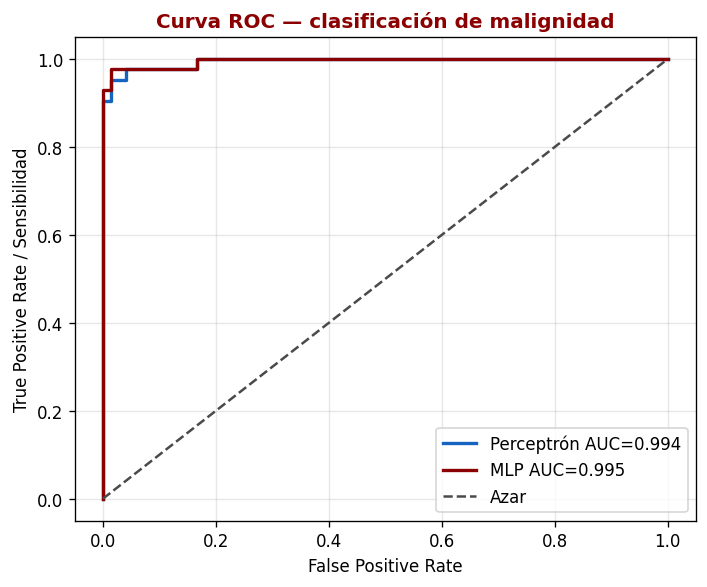

In [ ]:
# ── Curva ROC ───────────────────────────────────────────────────
# TODO 20: calcula ROC y AUC para ambos modelos
fpr_perc, tpr_perc, _ = roc_curve(y_test, y_prob_perc)
fpr_mlp,  tpr_mlp,  _ = roc_curve(y_test, y_prob_mlp)
auc_perc = roc_auc_score(y_test, y_prob_perc)
auc_mlp  = roc_auc_score(y_test, y_prob_mlp)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_perc, tpr_perc, color=UPCH_BLUE, lw=2, label=f'Perceptrón AUC={auc_perc:.3f}')
ax.plot(fpr_mlp, tpr_mlp, color=UPCH_RED, lw=2, label=f'MLP AUC={auc_mlp:.3f}')
ax.plot([0, 1], [0, 1], '--', color=UPCH_GRAY, label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate / Sensibilidad')
ax.set_title('Curva ROC — clasificación de malignidad', fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge6_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 6.3 — Tabla final comparativa

In [ ]:
# ── Tabla final comparativa ────────────────────────────────────
final_cols = ['accuracy', 'sensitivity_recall_malignant', 'specificity_benign',
              'precision_malignant', 'f1_malignant', 'roc_auc', 'tn', 'fp', 'fn', 'tp']

final_table = comparison[final_cols].copy()
final_table.index.name = 'Modelo'
final_table.round(4)

,accuracy,sensitivity_recall_malignant,specificity_benign,precision_malignant,f1_malignant,roc_auc,tn,fp,fn,tp
Modelo,,,,,,,,,,
Perceptrón,0.9737,0.9524,0.9861,0.9756,0.9639,0.9944,71,1,2,40
MLP,0.9737,0.9524,0.9861,0.9756,0.9639,0.9954,71,1,2,40


### Paso 6.4 — Interpretación final

**📝 Tu respuesta (edita esta celda):**

**1. Tabla resumen — completa con los valores obtenidos:**

| Modelo | Accuracy | Sensibilidad maligno | Especificidad benigno | F1 maligno | ROC-AUC | FN | FP |
|---|---:|---:|---:|---:|---:|---:|---:|
| Perceptrón | 0.9737 | 0.9524 | 0.9861 | 0.9639 | 0.9944 | 2 | 1 |
| MLP | 0.9737 | 0.9524 | 0.9861 | 0.9639 | 0.9954 | 2 | 1 |

---

**2. ¿Cuál modelo elegirías para este problema diagnóstico y por qué?**

Elegiría el Perceptrón pues ambos modelos presentan un rendimiento prácticamente idéntico en las métricas de test, sin embargo, es la primera es la mejor opción por su arquitectura más simple y eficiente, menor sobreajuste e interpretabilidad clínica,
___

**3. ¿Qué ocurre al bajar el umbral de decisión de 0.50 a 0.30? Discute sensibilidad, especificidad, FN y FP.**

Al bajar el umbral a 0.30, el modelo se vuelve más sensible a casos malignos. Lo cual provoca que la sensibilidad aumente, ya que es más fácil que los casos verdaderamente positivos superen el nuevo umbral aunque esto puede aumentar los falsos positivos. En el caso de falsos negativos, estos disminuyen al igual que disminuye la especificidad pues clasificará erróneamente más casos sanos como positivos.
___

**4. ¿Por qué no basta con reportar accuracy en este problema?**

No basta porque accuracy es una métrica engañosa en medicina. El modelo puede priorizar erróneamente la clase mayoritaria y obtener buen accuracy sin detectar la enfermedad. En oncología diagnóstica, un error en un falso negativo (FN) es críticamente más costoso que un falso positivo (FP), por lo cual en clínica es más prudente usar recall.
___

**5. ¿Qué limitaciones tendría este modelo antes de usarlo en un entorno clínico real?**

Falta de validación externa: Se necesita probar el modelo con datos externos de hospitales o escáneres distintos para asegurar su capacidad de generalización.

Caja negra (MLP): La falta de interpretabilidad directa dificulta que los médicos confíen en el criterio del algoritmo.

Costo de falsos negativos ($FN = 2$): A pesar de tener buen rendimiento, los pacientes con tumores malignos no detectados sí implican un riesgo crítico. Por ello, el modelo requeriría de un reajuste y de supervisión médica.
___


---
## Checklist de entrega

Antes de entregar, verifica que tu notebook incluya:

- [x] Respuestas conceptuales completas sobre neurona artificial, perceptrón, MLP y backpropagation.
- [x] Carga correcta del dataset y recodificación clínica: `0=benigno`, `1=maligno`.
- [x] Split estratificado train/validation/test.
- [x] Escalado ajustado solo con train.
- [x] Conversión correcta a tensores y uso de `TensorDataset` + `DataLoader`.
- [x] Definición funcional de `LogisticPerceptron` y `MLPClassifier`.
- [x] Loop explícito de PyTorch con `forward`, `loss`, `zero_grad`, `backward`, `step`.
- [x] Curvas de pérdida de train/validation.
- [x] Matriz de confusión, sensibilidad, especificidad, precisión, F1 y ROC-AUC.
- [x] Análisis de umbral de decisión y discusión clínica de falsos negativos.
- [x] Interpretación final comparando modelo lineal vs MLP.
